# PSet 4 Household Sanity Check

This notebook follows a staged sanity check for the modular `Household` framework.

- **Stage A:** Compare six package solvers on one shared nonlinear asset grid (discrete Rouwenhorst).
- **Stage B:** Compare solvers using continuous quadrature income process.
- **Stage C:** Ergodic distribution comparison across all discrete solvers.
- **Stage D:** Ergodic distribution comparison across all continuous solvers.

In [1]:
import importlib
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Repo-root detection so notebook runs from different launch locations.
REPO_ROOT = None
for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (p / "hetmacro").exists():
        REPO_ROOT = p
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate repository root containing 'hetmacro'.")
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import hetmacro.solvers.collocation_vfi
import hetmacro.solvers.howard
import hetmacro.solvers.howard_grid
import hetmacro.solvers.egm
import hetmacro.solvers.grid_vfi
import hetmacro.solvers.policy_iteration
import hetmacro.household
import hetmacro.solvers
importlib.reload(hetmacro.household)
importlib.reload(hetmacro.solvers.collocation_vfi)
importlib.reload(hetmacro.solvers.howard)
importlib.reload(hetmacro.solvers.howard_grid)
importlib.reload(hetmacro.solvers.egm)
importlib.reload(hetmacro.solvers.grid_vfi)
importlib.reload(hetmacro.solvers.policy_iteration)
importlib.reload(hetmacro.solvers)

from hetmacro.grids import make_grid_1d
from hetmacro.household import Household, SolvedPolicy
from hetmacro.income_process import RouwenhorstIncome, ContinuousQuadratureIncome
from hetmacro.solvers import (
    GridVFI,
    HowardImprovement,
    HowardGrid,
    PolicyFunctionIteration,
    EGM,
    CollocationVFI_Spline,
    CollocationVFI_Chebyshev,
)
from hetmacro.dp_tools import solve_euler_one_asset
from hetmacro.utils import crra_marginal


In [2]:
# PSet 4 parameterization
beta, r, rho, sigma, gamma = 0.95, 0.02, 0.90, 0.20, 1.5
a_max, n_a = 50.0, 201
n_z = 11
K = 11

tol = 1e-8
max_iter = 2000


In [3]:
# Stage A grids and baseline household (discrete Rouwenhorst process)
a_grid = make_grid_1d(0.0, a_max, n_a, spacing="power", power=2.0)
income_disc = RouwenhorstIncome.from_ar1(n=n_z, rho=rho, sigma=sigma)
hh_disc = Household(
    income_process=income_disc,
    a_grid=a_grid,
    beta=beta,
    gamma=gamma,
    r=r,
)

print(f"a_grid points: {a_grid.size}, min={a_grid.min():.4f}, max={a_grid.max():.4f}")
print(f"z states (discrete): {hh_disc.z_grid.size}")


a_grid points: 201, min=0.0000, max=50.0000
z states (discrete): 11


In [4]:
# Stage A: run six package solvers
solver_specs = [
    ("GridVFI", GridVFI(tol=tol, max_iter=max_iter)),
    ("HowardImprovement", HowardImprovement(n_a_breaks=51, tol=1e-6, max_iter=120, n_warmup=2, verbose=False)),
    ("PolicyFunctionIteration", PolicyFunctionIteration(tol=1e-10, max_iter=500)),
    ("EGM", EGM(tol=tol, max_iter=max_iter)),
    ("CollocationVFI_Spline", CollocationVFI_Spline(n_a_breaks=51, tol=tol, max_iter=max_iter, verbose=False)),
    ("CollocationVFI_Chebyshev", CollocationVFI_Chebyshev(n_basis_a=35, tol=tol, max_iter=max_iter, verbose=False)),
]

solutions = {}
timings = {}

for name, solver in solver_specs:
    t0 = time.time()
    sol = hh_disc.solve(solver)
    elapsed = time.time() - t0
    solutions[name] = sol
    timings[name] = elapsed
    print(f"{name:24s} {elapsed:8.3f}s")

egm_sol = solutions["EGM"]


/Users/rafaellincoln/Dropbox/Academia/Macroeconomics/Heterogeneity in Macro/Heterogeneity In Macroeconomics - Github/hetmacro/utils.py:15: RuntimeWarning: invalid value encountered in power
  return c ** (1.0 - gamma) / (1.0 - gamma)


GridVFI                     4.550s
HowardImprovement           0.408s
PolicyFunctionIteration     0.381s
EGM                         0.460s
CollocationVFI_Spline       8.800s
CollocationVFI_Chebyshev   18.026s


In [5]:
# Stage A quick feasibility diagnostics
print("Solver feasibility diagnostics")
print("-" * 88)
print("{:<24s} {:>14s} {:>12s} {:>12s}".format("solver", "share(c<=0)", "mono a'", "bound hits"))
print("-" * 88)

for name, sol in solutions.items():
    share_nonpos_c = float(np.mean(sol.policy_c <= 0.0))
    mono_ap = bool(np.all(np.diff(sol.policy_a, axis=1) >= -1e-10))
    share_bound = float(np.mean(np.isclose(sol.policy_a, a_grid[0], atol=1e-10)))
    print(f"{name:24s} {share_nonpos_c:14.6f} {str(mono_ap):>12s} {share_bound:12.6f}")


Solver feasibility diagnostics
----------------------------------------------------------------------------------------
solver                      share(c<=0)      mono a'   bound hits
----------------------------------------------------------------------------------------
GridVFI                        0.000000         True     0.012212
HowardImprovement              0.000000         True     0.005427
PolicyFunctionIteration        0.000000         True     0.005427
EGM                            0.000000         True     0.012212
CollocationVFI_Spline          0.000000         True     0.005427
CollocationVFI_Chebyshev       0.000000         True     0.008141


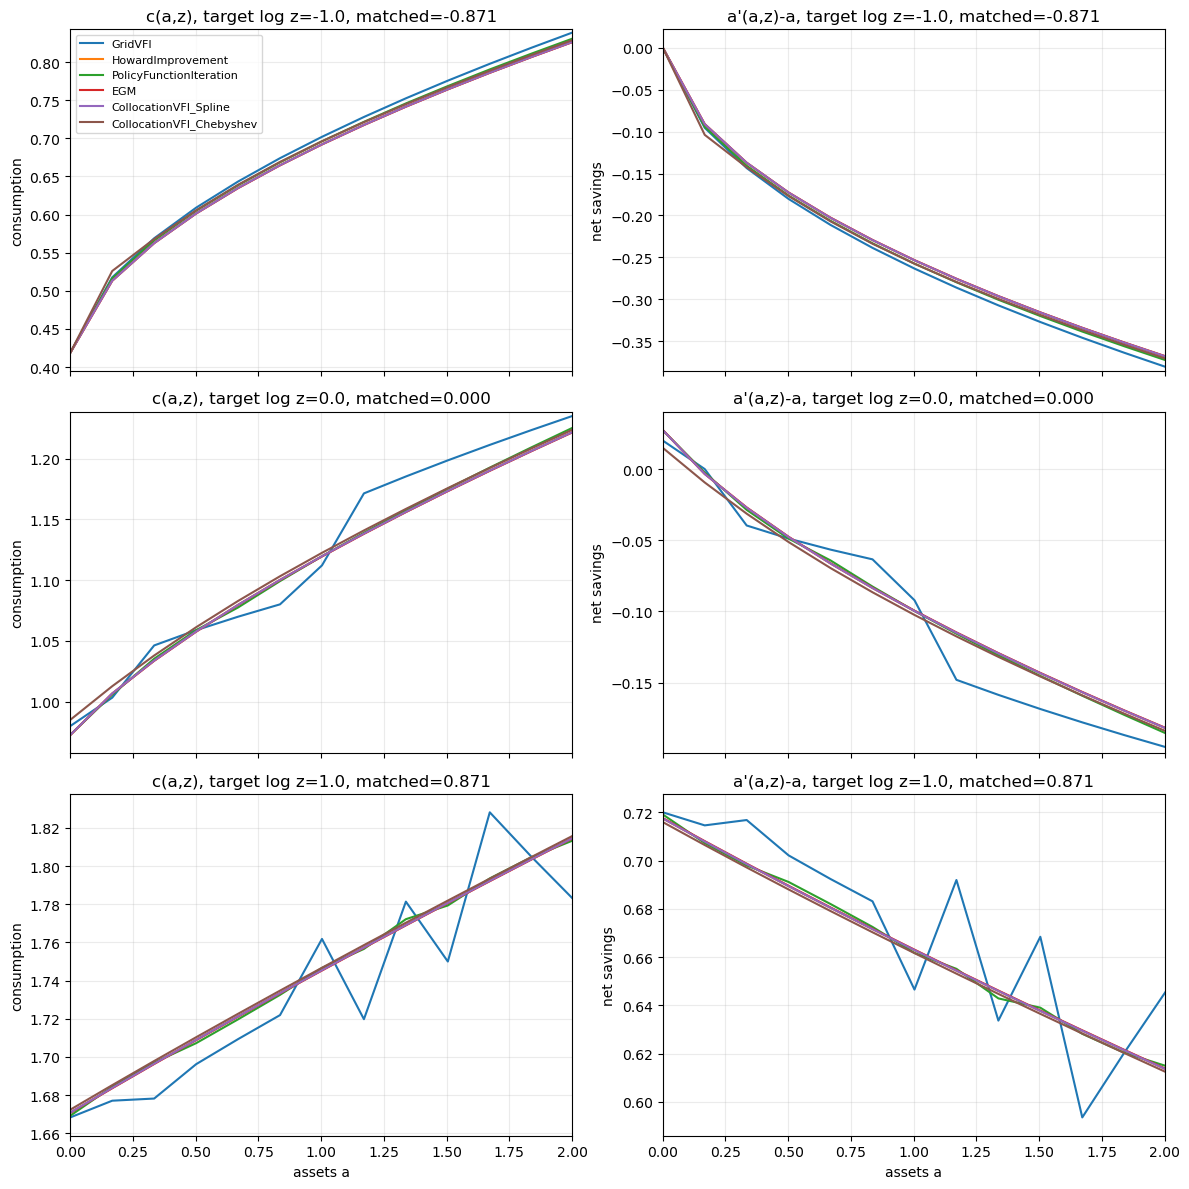

In [6]:
# Stage A policy overlays on a common evaluation mesh
a_common = np.linspace(0.0, a_max, 300)
a_plot_max = 2.0  # zoom near borrowing limit to see curvature
z_log_targets = np.array([-1.0, 0.0, 1.0])

# RouwenhorstIncome stores z_grid in levels, so map targets in log-space.
z_log_disc = np.log(hh_disc.z_grid)
z_idx_disc = np.array([int(np.argmin(np.abs(z_log_disc - z0))) for z0 in z_log_targets])
z_levels_disc = hh_disc.z_grid[z_idx_disc]
z_log_levels_disc = z_log_disc[z_idx_disc]

A_common, Z_common = np.meshgrid(a_common, z_levels_disc)
stageA_eval = {}
for name, sol in solutions.items():
    out = sol.evaluate(A_common, Z_common)
    stageA_eval[name] = out

plot_names = list(stageA_eval.keys())

fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True)
for i in range(3):
    ax_c = axes[i, 0]
    ax_a = axes[i, 1]
    for name in plot_names:
        out = stageA_eval[name]
        ax_c.plot(a_common, out["c"][i], label=name, linewidth=1.5)
        ax_a.plot(a_common, out["a"][i] - a_common, label=name, linewidth=1.5)
    ax_c.set_title(f"c(a,z), target log z={z_log_targets[i]:.1f}, matched={z_log_levels_disc[i]:.3f}")
    ax_a.set_title(f"a'(a,z)-a, target log z={z_log_targets[i]:.1f}, matched={z_log_levels_disc[i]:.3f}")
    ax_c.set_ylabel("consumption")
    ax_a.set_ylabel("net savings")
    ax_c.grid(alpha=0.25)
    ax_a.grid(alpha=0.25)

# Data-driven ylim so curves are not distorted in the zoomed region
a_mask = a_common <= a_plot_max
pad_frac = 0.06
for i in range(3):
    c_vals = np.concatenate([stageA_eval[name]["c"][i][a_mask] for name in plot_names])
    s_vals = np.concatenate([(stageA_eval[name]["a"][i] - a_common)[a_mask] for name in plot_names])
    c_lo, c_hi = c_vals.min(), c_vals.max()
    s_lo, s_hi = s_vals.min(), s_vals.max()
    pad_c = max(pad_frac * (c_hi - c_lo), 1e-6)
    pad_s = max(pad_frac * (s_hi - s_lo), 1e-6)
    axes[i, 0].set_ylim(c_lo - pad_c, c_hi + pad_c)
    axes[i, 1].set_ylim(s_lo - pad_s, s_hi + pad_s)

for i in range(3):
    axes[i, 0].set_xlim(0, a_plot_max)
    axes[i, 1].set_xlim(0, a_plot_max)

axes[-1, 0].set_xlabel("assets a")
axes[-1, 1].set_xlabel("assets a")
axes[0, 0].legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


In [7]:
# Stage A quantitative comparison on common mesh: L_inf and L2 vs EGM
ref = stageA_eval["EGM"]
metrics = []
for name, out in stageA_eval.items():
    da = out["a"] - ref["a"]
    dc = out["c"] - ref["c"]
    metrics.append((
        name,
        float(np.max(np.abs(da))),
        float(np.sqrt(np.mean(da**2))),
        float(np.max(np.abs(dc))),
        float(np.sqrt(np.mean(dc**2))),
        float(timings[name]),
    ))

print("Comparison vs EGM on common mesh")
print("-" * 110)
print("{:<24s} {:>12s} {:>12s} {:>12s} {:>12s} {:>10s}".format("solver", "L_inf a'", "L2 a'", "L_inf c", "L2 c", "time(s)"))
print("-" * 110)
for row in metrics:
    name, linf_a, l2_a, linf_c, l2_c, tsec = row
    print(f"{name:24s} {linf_a:12.4e} {l2_a:12.4e} {linf_c:12.4e} {l2_c:12.4e} {tsec:10.3f}")


Comparison vs EGM on common mesh
--------------------------------------------------------------------------------------------------------------
solver                       L_inf a'        L2 a'      L_inf c         L2 c    time(s)
--------------------------------------------------------------------------------------------------------------
GridVFI                    2.4532e-01   9.8709e-02   2.4532e-01   9.8709e-02      4.550
HowardImprovement          2.6104e-04   1.6859e-04   2.6104e-04   1.6859e-04      0.408
PolicyFunctionIteration    9.6574e-03   5.1150e-03   9.6574e-03   5.1150e-03      0.381
EGM                        0.0000e+00   0.0000e+00   0.0000e+00   0.0000e+00      0.460
CollocationVFI_Spline      2.6104e-04   1.6861e-04   2.6104e-04   1.6861e-04      8.800
CollocationVFI_Chebyshev   1.2765e-02   1.2111e-03   1.2765e-02   1.2111e-03     18.026


In [8]:
# Stage A Euler residual diagnostic for EGM on common mesh
Pi = hh_disc.income_process.Pi
idx = z_idx_disc
egm_eval = stageA_eval["EGM"]

residuals = []
for k, iz in enumerate(idx):
    c_now = egm_eval["c"][k]
    a_next = egm_eval["a"][k]

    c_next_all = np.empty((len(idx), a_common.size))
    for j, izp in enumerate(idx):
        z_next = hh_disc.z_grid[izp]
        c_next_all[j] = egm_sol.evaluate(a_next, np.full_like(a_next, z_next))["c"]

    rhs = (beta * (1.0 + r) * (Pi[iz, idx] @ (c_next_all ** (-gamma)))) ** (-1.0 / gamma)
    unconstrained = a_next > (a_grid[0] + 1e-10)
    resid = np.abs(rhs - c_now) / np.maximum(c_now, 1e-12)
    residuals.append(resid[unconstrained])

all_res = np.concatenate([x for x in residuals if x.size > 0])
print("EGM Euler residual (unconstrained states, common mesh)")
print(f"max:    {all_res.max():.4e}")
print(f"median: {np.median(all_res):.4e}")
print(f"p95:    {np.quantile(all_res, 0.95):.4e}")


EGM Euler residual (unconstrained states, common mesh)
max:    4.2657e-01
median: 3.4816e-01
p95:    3.9969e-01


## Stage C: Ergodic Distribution Comparison (Discrete)

Compute the stationary income-asset distribution for each Stage A solver and
compare. All solvers return `SolvedPolicy` on the same household grid, so
`compute_ergodic()` should work uniformly via the discrete path:
`get_lottery` → `compute_joint_transition_matrix` (sparse) → `stationary_eigenvector`.

In [13]:
# Stage C: compute ergodic distribution for all Stage A solvers
importlib.reload(hetmacro.household)
from hetmacro.household import Household, SolvedPolicy

# Rebuild household to pick up reloaded modules
hh_disc = Household(
    income_process=income_disc,
    a_grid=a_grid,
    beta=beta,
    gamma=gamma,
    r=r,
)

ergodic_disc = {}
agg_disc = {}

for name, sol in solutions.items():
    print(f"  {name:<24s} ...", end=" ", flush=True)
    t0 = time.time()
    hh_disc.solved_policy = sol
    g = hh_disc.compute_ergodic()
    agg = hh_disc.compute_aggregates()
    elapsed = time.time() - t0
    ergodic_disc[name] = g
    agg_disc[name] = agg
    print(f"done in {elapsed:.3f}s  sum={g.sum():.8f}  mean_A={agg['A']:.4f}")

print("\nAll Stage A ergodic distributions computed.")

  GridVFI                  ... done in 1.520s  sum=1.00000000  mean_A=1.5447
  HowardImprovement        ... done in 1.573s  sum=1.00000000  mean_A=1.5668
  PolicyFunctionIteration  ... done in 1.603s  sum=1.00000000  mean_A=1.5650
  EGM                      ... done in 3.338s  sum=1.00000000  mean_A=1.5683
  CollocationVFI_Spline    ... done in 2.930s  sum=1.00000000  mean_A=1.5668
  CollocationVFI_Chebyshev ... done in 3.171s  sum=1.00000000  mean_A=1.5444

All Stage A ergodic distributions computed.


In [14]:
# Stage C: comparison table and smoke test assertions
ref_name = "EGM"
ref_g = ergodic_disc[ref_name]
ref_agg = agg_disc[ref_name]

print("Stage C: Ergodic Distribution Comparison (discrete)")
print("-" * 100)
print(f"{'Solver':<24s} {'sum(g)':>10s} {'mean_A':>10s} {'mean_C':>10s} {'mean_Y':>10s} {'L_inf vs EGM':>14s} {'L2 vs EGM':>12s}")
print("-" * 100)
for name in solutions:
    g = ergodic_disc[name]
    agg = agg_disc[name]
    linf = float(np.max(np.abs(g - ref_g)))
    l2 = float(np.sqrt(np.mean((g - ref_g)**2)))
    print(f"{name:<24s} {g.sum():10.6f} {agg['A']:10.4f} {agg['C']:10.4f} {agg['Y']:10.4f} {linf:14.4e} {l2:12.4e}")

# Smoke test assertions
print("\nSmoke test assertions:")
n_pass = 0
n_total = 0
for name, g in ergodic_disc.items():
    agg = agg_disc[name]
    errors = []
    if g.shape != (n_z, n_a):
        errors.append(f"shape {g.shape} != ({n_z}, {n_a})")
    if abs(g.sum() - 1.0) > 1e-6:
        errors.append(f"sum={g.sum():.8f}")
    if (g < -1e-10).any():
        errors.append(f"negative entries: min={g.min():.2e}")
    # Aggregate comparison: 10% relative tolerance (GridVFI is coarse)
    if ref_agg["A"] > 0 and abs(agg["A"] - ref_agg["A"]) / ref_agg["A"] > 0.10:
        errors.append(f"mean_A off by {abs(agg['A'] - ref_agg['A'])/ref_agg['A']*100:.1f}%")

    n_total += 1
    if errors:
        print(f"  FAIL  {name:<24s} {', '.join(errors)}")
    else:
        n_pass += 1
        print(f"  PASS  {name}")

print(f"\n{n_pass}/{n_total} solvers passed discrete ergodic smoke test.")

Stage C: Ergodic Distribution Comparison (discrete)
----------------------------------------------------------------------------------------------------
Solver                       sum(g)     mean_A     mean_C     mean_Y   L_inf vs EGM    L2 vs EGM
----------------------------------------------------------------------------------------------------
GridVFI                    1.000000     1.5447     1.1415     1.1106     7.3923e-03   4.1832e-04
HowardImprovement          1.000000     1.5668     1.1419     1.1106     1.5866e-04   6.5722e-06
PolicyFunctionIteration    1.000000     1.5650     1.1419     1.1106     7.3785e-04   3.7120e-05
EGM                        1.000000     1.5683     1.1420     1.1106     0.0000e+00   0.0000e+00
CollocationVFI_Spline      1.000000     1.5668     1.1419     1.1106     1.5866e-04   6.5728e-06
CollocationVFI_Chebyshev   1.000000     1.5444     1.1415     1.1106     1.9448e-02   5.6212e-04

Smoke test assertions:
  PASS  GridVFI
  PASS  HowardImprovement
 

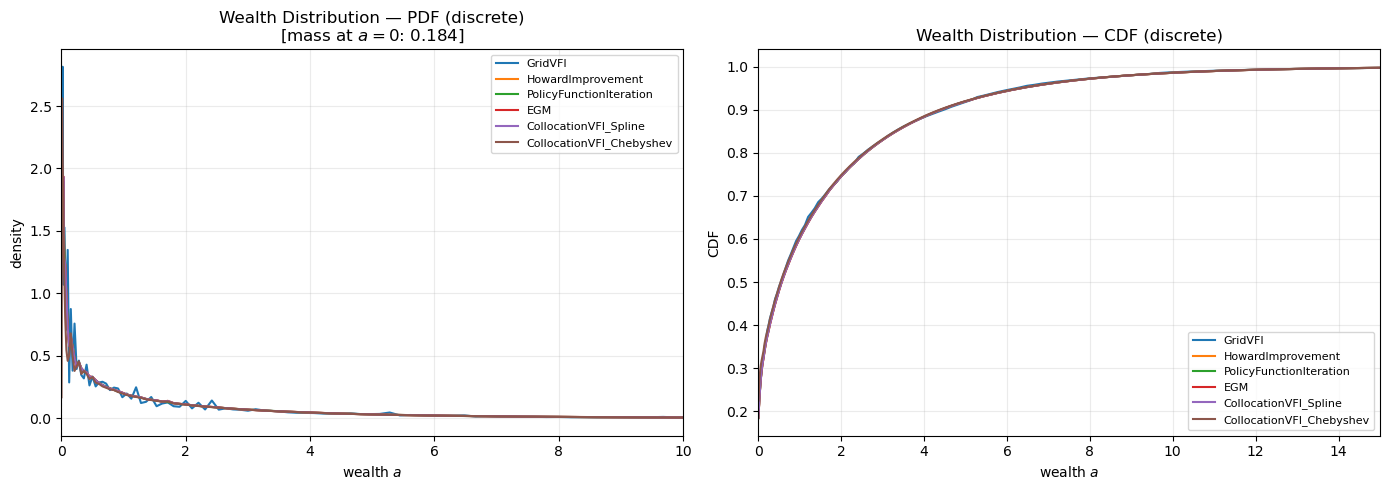

In [20]:
# Stage C: marginal wealth distribution plots (discrete)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grid spacing for mass-to-density conversion (exclude a=0 atom)
da = np.diff(a_grid, prepend=a_grid[0] - (a_grid[1] - a_grid[0]))

# PDF: skip first point (mass atom at borrowing constraint), plot interior density
ax = axes[0]
for name, g in ergodic_disc.items():
    marg_mass = g.sum(axis=0)
    density = marg_mass[1:] / da[1:]
    ax.plot(a_grid[1:], density, label=name, linewidth=1.5)
# Mark constraint mass as text annotation on first solver
first_mass = next(iter(ergodic_disc.values())).sum(axis=0)[0]
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xlim(0, 10)
ax.set_xlabel("wealth $a$")
ax.set_ylabel("density")
ax.set_title(f"Wealth Distribution — PDF (discrete)\n[mass at $a=0$: {first_mass:.3f}]")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# CDF
ax = axes[1]
for name, g in ergodic_disc.items():
    marg_mass = g.sum(axis=0)
    cdf = np.cumsum(marg_mass)
    cdf /= cdf[-1]
    ax.plot(a_grid, cdf, label=name, linewidth=1.5)
ax.set_xlim(0, 15)
ax.set_xlabel("wealth $a$")
ax.set_ylabel("CDF")
ax.set_title("Wealth Distribution — CDF (discrete)")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Stage B: Continuous quadrature solver comparison

All four non-collocation solvers now support `expectation="quadrature"` mode,
using `ContinuousQuadratureIncome` and Gaussian quadrature expectations.
This section mirrors the Stage A comparison using package solvers only.

Note: GridVFI with the default 41-point z-grid may be slow due to the
O(n_z * n_a^2) grid search. HowardGrid accelerates convergence via exact
policy evaluation.

In [21]:
# Stage B: continuous quadrature household and solver suite
income_cont = ContinuousQuadratureIncome(rho=rho, sigma_eps=sigma, n_quad=K)
hh_cont = Household(
    income_process=income_cont,
    a_grid=a_grid,
    beta=beta,
    gamma=gamma,
    r=r,
)

print(f"Stage B z_grid (log space): {hh_cont.z_grid.size} points")
print(f"Stage B y_grid range: [{hh_cont.y_grid.min():.4f}, {hh_cont.y_grid.max():.4f}]")

stageB_specs = [
    ("EGM", EGM(tol=tol, max_iter=max_iter, expectation="quadrature")),
    ("GridVFI", GridVFI(tol=tol, max_iter=max_iter, expectation="quadrature")),
    ("PFI", PolicyFunctionIteration(tol=1e-10, max_iter=500, expectation="quadrature", verbose=False)),
    ("HowardGrid", HowardGrid(tol=tol, max_iter=200, expectation="quadrature")),
]

stageB_solutions = {}
stageB_timings = {}

for name, solver in stageB_specs:
    print(f"  Running {name} (quadrature) ...", end=" ", flush=True)
    t0 = time.time()
    sol = hh_cont.solve(solver)
    elapsed = time.time() - t0
    stageB_solutions[name] = sol
    stageB_timings[name] = elapsed
    print(f"done in {elapsed:.3f}s")

print("\nStage B solvers complete.")


Stage B z_grid (log space): 41 points
Stage B y_grid range: [0.2525, 3.9610]
  Running EGM (quadrature) ... done in 0.924s
  Running GridVFI (quadrature) ... done in 19.382s
  Running PFI (quadrature) ... done in 4.478s
  Running HowardGrid (quadrature) ... done in 5.334s

Stage B solvers complete.


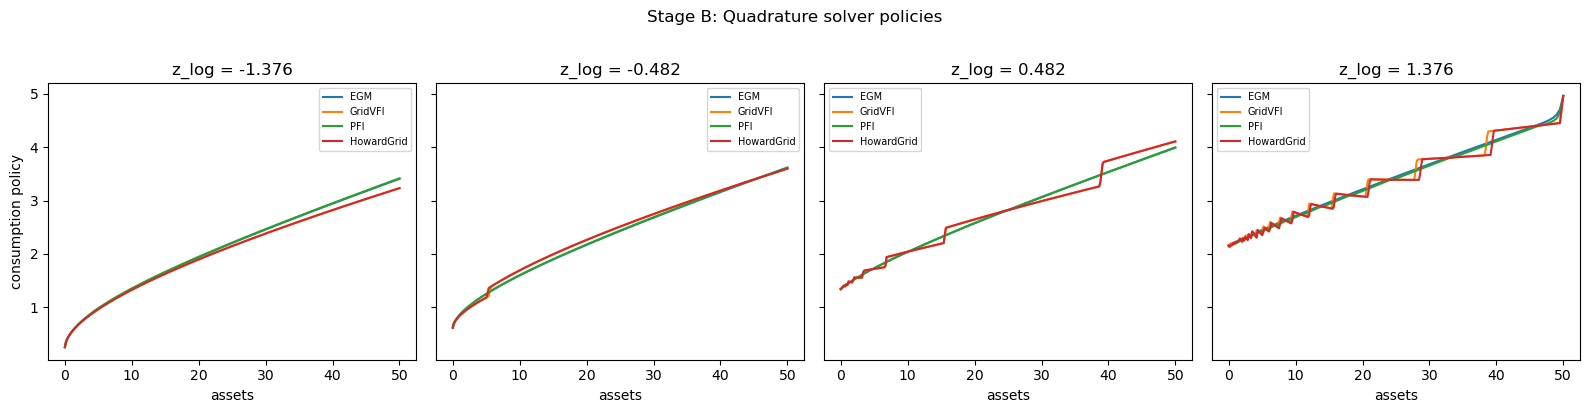

In [22]:
# Stage B policy overlays on a common evaluation mesh
a_common_B = np.linspace(0.0, a_max, 300)
z_log_cont = hh_cont.z_grid
n_plot = min(4, z_log_cont.size)
idx_B = np.round(np.linspace(0, z_log_cont.size - 1, n_plot)).astype(int)

stageB_eval = {}
for name, sol in stageB_solutions.items():
    A_mesh, Z_mesh = np.meshgrid(a_common_B, z_log_cont[idx_B])
    stageB_eval[name] = sol.evaluate(A_mesh, Z_mesh)

plot_names_B = list(stageB_solutions.keys())
fig, axes = plt.subplots(1, len(idx_B), figsize=(4 * len(idx_B), 4), sharey=True)
if len(idx_B) == 1:
    axes = [axes]
for k, iz in enumerate(idx_B):
    ax = axes[k]
    for name in plot_names_B:
        ax.plot(a_common_B, stageB_eval[name]["c"][k], label=name)
    ax.set_title(f"z_log = {z_log_cont[iz]:.3f}")
    ax.set_xlabel("assets")
    if k == 0:
        ax.set_ylabel("consumption policy")
    ax.legend(fontsize=7)
fig.suptitle("Stage B: Quadrature solver policies", y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# Stage B quantitative comparison vs quadrature EGM
ref_B = stageB_eval["EGM"]
print(f"{'Solver':<15} {'a L_inf':>12} {'a L2':>12} {'c L_inf':>12} {'c L2':>12}")
for name in plot_names_B:
    ev = stageB_eval[name]
    da = ev["a"] - ref_B["a"]
    dc = ev["c"] - ref_B["c"]
    a_linf = np.max(np.abs(da))
    a_l2 = np.sqrt(np.mean(da**2))
    c_linf = np.max(np.abs(dc))
    c_l2 = np.sqrt(np.mean(dc**2))
    print(f"{name:<15} {a_linf:>12.4e} {a_l2:>12.4e} {c_linf:>12.4e} {c_l2:>12.4e}")

Solver               a L_inf         a L2      c L_inf         c L2
EGM               0.0000e+00   0.0000e+00   0.0000e+00   0.0000e+00
GridVFI           2.5535e-01   9.1959e-02   2.5535e-01   9.1959e-02
PFI               7.1377e-02   1.6256e-02   7.1377e-02   1.6256e-02
HowardGrid        2.5535e-01   9.2909e-02   2.5535e-01   9.2909e-02


In [24]:
# Stage B Euler residuals
for name in stageB_solutions:
    hh_cont.solved_policy = stageB_solutions[name]
    euler = hh_cont.euler_check()
    unconstrained = stageB_solutions[name].policy_a > (a_grid[0] + 1e-10)
    res_unc = np.abs(euler[unconstrained])
    if res_unc.size > 0:
        print(f"{name:<15}  Euler max: {res_unc.max():.4e}  median: {np.median(res_unc):.4e}  p95: {np.quantile(res_unc, 0.95):.4e}")
    else:
        print(f"{name:<15}  no unconstrained states")

EGM              Euler max: 1.3184e-01  median: 2.4684e-02  p95: 5.8397e-02
GridVFI          Euler max: 1.3256e-01  median: 3.4200e-02  p95: 7.6842e-02
PFI              Euler max: 1.3256e-01  median: 2.4341e-02  p95: 5.9297e-02
HowardGrid       Euler max: 1.3256e-01  median: 3.4124e-02  p95: 7.6654e-02


In [25]:
# Stage B ergodic distribution (quadrature EGM)
hh_cont.solved_policy = stageB_solutions["EGM"]
g_cont = hh_cont.compute_ergodic()
print(f"Ergodic distribution shape: {g_cont.shape}")
print(f"Sum of distribution: {g_cont.sum():.6f}")
print(f"Mean assets: {np.sum(g_cont * a_grid[None, :]):.4f}")

Ergodic distribution shape: (41, 201)
Sum of distribution: 1.000000
Mean assets: 1.5898


## Stage B extension: Naive Euler and Howard Euler

This adds the two new Euler equation solvers for continuous income and compares them with Stage B EGM on the same household and grid.

Running new Euler iteration solvers on the Stage B household
  NaiveEuler   done in   1.954s   iter=128
  HowardEuler  done in   1.209s   iter=13

Comparison vs Stage B EGM
Solver          a_max_abs    c_max_abs   a_allclose   c_allclose
NaiveEuler     2.4382e-02   3.5854e-02         True         True
HowardEuler    2.6711e-02   3.5817e-02         True         True


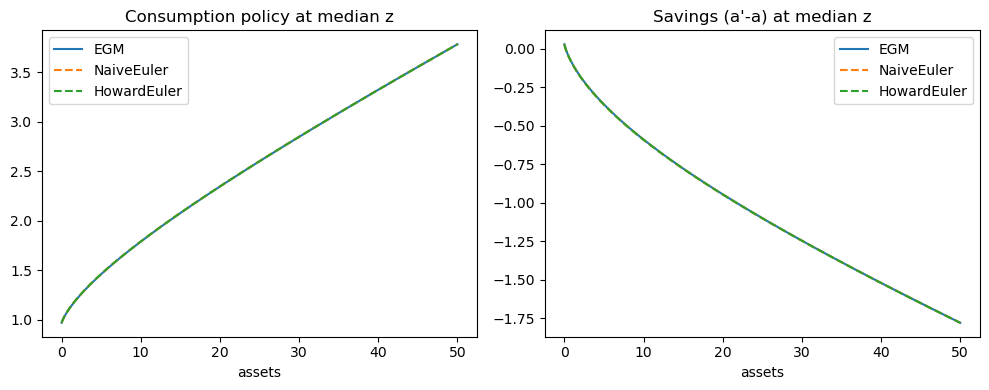

In [26]:
from hetmacro.solvers import NaiveEulerIteration, HowardEulerIteration

new_solver_specs = [
    ("NaiveEuler", NaiveEulerIteration(tol=1e-6, max_iter=400, root_method="broyden", verbose=False)),
    ("HowardEuler", HowardEulerIteration(tol=1e-6, max_iter=200, n_warmup=10, root_method="broyden", verbose=False)),
]

stageB_new_solutions = {}
print("Running new Euler iteration solvers on the Stage B household")
for name, solver in new_solver_specs:
    t0 = time.time()
    sol = hh_cont.solve(solver)
    elapsed = time.time() - t0
    stageB_new_solutions[name] = sol
    nit = getattr(solver, "n_iter_", None)
    print(f"  {name:<12} done in {elapsed:7.3f}s   iter={nit}")

# Compare against Stage B EGM baseline
ref = stageB_solutions["EGM"]
print("\nComparison vs Stage B EGM")
print(f"{'Solver':<12} {'a_max_abs':>12} {'c_max_abs':>12} {'a_allclose':>12} {'c_allclose':>12}")
for name, sol in stageB_new_solutions.items():
    da = np.max(np.abs(sol.policy_a - ref.policy_a))
    dc = np.max(np.abs(sol.policy_c - ref.policy_c))
    a_ok = np.allclose(sol.policy_a, ref.policy_a, atol=1e-1, rtol=5e-2)
    c_ok = np.allclose(sol.policy_c, ref.policy_c, atol=5e-2, rtol=5e-2)
    print(f"{name:<12} {da:12.4e} {dc:12.4e} {str(a_ok):>12} {str(c_ok):>12}")

# Quick overlay at median z for visual comparison
iz_mid = len(hh_cont.z_grid) // 2
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(a_grid, ref.policy_c[iz_mid], label="EGM")
for name, sol in stageB_new_solutions.items():
    plt.plot(a_grid, sol.policy_c[iz_mid], "--", label=name)
plt.title("Consumption policy at median z")
plt.xlabel("assets")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(a_grid, ref.policy_a[iz_mid] - a_grid, label="EGM")
for name, sol in stageB_new_solutions.items():
    plt.plot(a_grid, sol.policy_a[iz_mid] - a_grid, "--", label=name)
plt.title("Savings (a'-a) at median z")
plt.xlabel("assets")
plt.legend()
plt.tight_layout()
plt.show()

## Stage D: Ergodic Distribution Comparison (Continuous Quadrature)

Compute the stationary distribution for all Stage B solvers using the
continuous quadrature path: `linear_basis_matrix` + `tensor_basis_matrix`
per Gauss-Hermite node → sparse Q → `stationary_eigenvector`.

In [27]:
# Stage D: compute ergodic distribution for all Stage B solvers (continuous)
importlib.reload(hetmacro.household)
from hetmacro.household import Household, SolvedPolicy

hh_cont = Household(
    income_process=income_cont,
    a_grid=a_grid,
    beta=beta,
    gamma=gamma,
    r=r,
)

# Merge Stage B solutions
all_cont_solutions = {**stageB_solutions, **stageB_new_solutions}

ergodic_cont = {}
agg_cont = {}

for name, sol in all_cont_solutions.items():
    print(f"  {name:<15s} ...", end=" ", flush=True)
    t0 = time.time()
    hh_cont.solved_policy = sol
    g = hh_cont.compute_ergodic()
    agg = hh_cont.compute_aggregates()
    elapsed = time.time() - t0
    ergodic_cont[name] = g
    agg_cont[name] = agg
    print(f"done in {elapsed:.3f}s  sum={g.sum():.8f}  mean_A={agg['A']:.4f}")

print("\nAll Stage B ergodic distributions computed.")

  EGM             ... done in 0.330s  sum=1.00000000  mean_A=1.5898
  GridVFI         ... done in 0.398s  sum=1.00000000  mean_A=1.5692
  PFI             ... done in 0.365s  sum=1.00000000  mean_A=1.5900
  HowardGrid      ... done in 0.362s  sum=1.00000000  mean_A=1.5729
  NaiveEuler      ... done in 0.338s  sum=1.00000000  mean_A=1.5744
  HowardEuler     ... done in 0.355s  sum=1.00000000  mean_A=1.5743

All Stage B ergodic distributions computed.


In [28]:
# Stage D: comparison table and smoke test (continuous)
ref_name_cont = "EGM"
ref_g_cont = ergodic_cont[ref_name_cont]
ref_agg_cont = agg_cont[ref_name_cont]

n_z_cont = hh_cont.z_grid.size

print("Stage D: Ergodic Distribution Comparison (continuous quadrature)")
print("-" * 100)
print(f"{'Solver':<15s} {'sum(g)':>10s} {'mean_A':>10s} {'mean_C':>10s} {'mean_Y':>10s} {'L_inf vs EGM':>14s} {'L2 vs EGM':>12s}")
print("-" * 100)
for name in all_cont_solutions:
    g = ergodic_cont[name]
    agg = agg_cont[name]
    linf = float(np.max(np.abs(g - ref_g_cont)))
    l2 = float(np.sqrt(np.mean((g - ref_g_cont)**2)))
    print(f"{name:<15s} {g.sum():10.6f} {agg['A']:10.4f} {agg['C']:10.4f} {agg['Y']:10.4f} {linf:14.4e} {l2:12.4e}")

# Smoke test assertions
print("\nSmoke test assertions:")
n_pass = 0
n_total = 0
for name, g in ergodic_cont.items():
    agg = agg_cont[name]
    errors = []
    if g.shape != (n_z_cont, n_a):
        errors.append(f"shape {g.shape} != ({n_z_cont}, {n_a})")
    if abs(g.sum() - 1.0) > 1e-6:
        errors.append(f"sum={g.sum():.8f}")
    if (g < -1e-10).any():
        errors.append(f"negative entries: min={g.min():.2e}")
    # 15% relative tolerance for continuous (solvers vary more)
    if ref_agg_cont["A"] > 0 and abs(agg["A"] - ref_agg_cont["A"]) / ref_agg_cont["A"] > 0.15:
        errors.append(f"mean_A off by {abs(agg['A'] - ref_agg_cont['A'])/ref_agg_cont['A']*100:.1f}%")

    n_total += 1
    if errors:
        print(f"  FAIL  {name:<15s} {', '.join(errors)}")
    else:
        n_pass += 1
        print(f"  PASS  {name}")

print(f"\n{n_pass}/{n_total} solvers passed continuous ergodic smoke test.")

Stage D: Ergodic Distribution Comparison (continuous quadrature)
----------------------------------------------------------------------------------------------------
Solver              sum(g)     mean_A     mean_C     mean_Y   L_inf vs EGM    L2 vs EGM
----------------------------------------------------------------------------------------------------
EGM               1.000000     1.5898     1.1431     1.1113     0.0000e+00   0.0000e+00
GridVFI           1.000000     1.5692     1.1427     1.1113     8.5992e-04   4.5045e-05
PFI               1.000000     1.5900     1.1431     1.1113     1.5614e-04   6.7492e-06
HowardGrid        1.000000     1.5729     1.1428     1.1113     8.6060e-04   4.5012e-05
NaiveEuler        1.000000     1.5744     1.1428     1.1113     3.2157e-03   9.7689e-05
HowardEuler       1.000000     1.5743     1.1428     1.1113     3.2184e-03   9.7688e-05

Smoke test assertions:
  PASS  EGM
  PASS  GridVFI
  PASS  PFI
  PASS  HowardGrid
  PASS  NaiveEuler
  PASS  HowardE

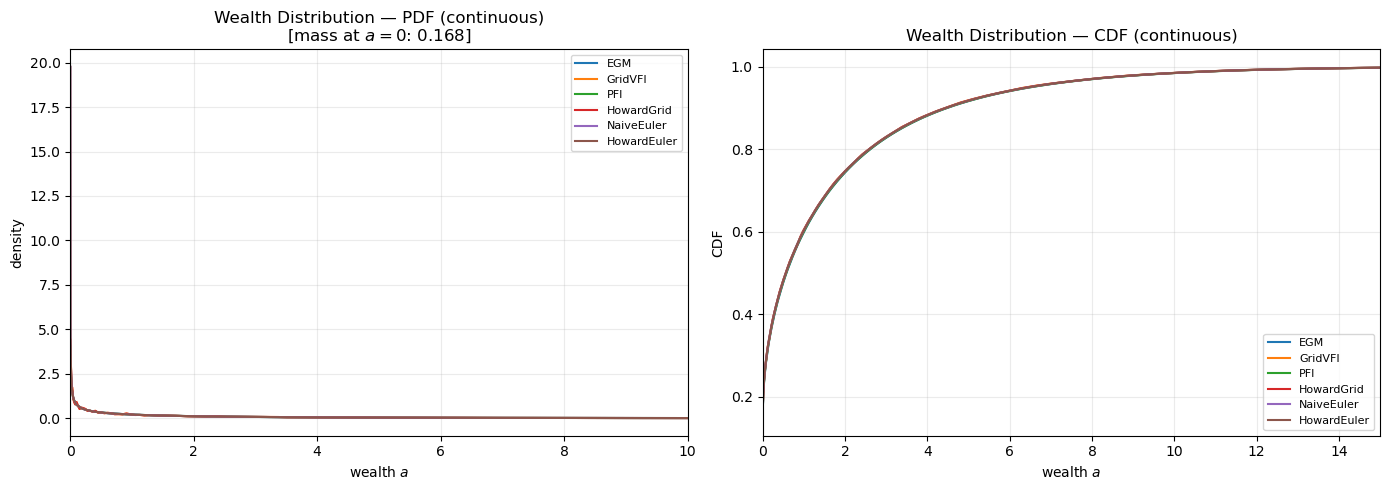

In [32]:
# Stage D: marginal wealth distribution plots (continuous)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

da = np.diff(a_grid, prepend=a_grid[0] - (a_grid[1] - a_grid[0]))

# PDF: skip first point (mass atom at borrowing constraint)
ax = axes[0]
for name, g in ergodic_cont.items():
    marg_mass = g.sum(axis=0)
    density = marg_mass[1:] / da[1:]
    ax.plot(a_grid[1:], density, label=name, linewidth=1.5)
first_mass = next(iter(ergodic_cont.values())).sum(axis=0)[0]
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xlim(0, 10)
ax.set_xlabel("wealth $a$")
ax.set_ylabel("density")
ax.set_title(f"Wealth Distribution — PDF (continuous)\n[mass at $a=0$: {first_mass:.3f}]")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# CDF
ax = axes[1]
for name, g in ergodic_cont.items():
    marg_mass = g.sum(axis=0)
    cdf = np.cumsum(marg_mass)
    cdf /= cdf[-1]
    ax.plot(a_grid, cdf, label=name, linewidth=1.5)
ax.set_xlim(0, 15)
ax.set_xlabel("wealth $a$")
ax.set_ylabel("CDF")
ax.set_title("Wealth Distribution — CDF (continuous)")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()